# Focused Comparison: data vs simulation vs smeared simulation

This notebook compares only `mpi0`, `mmiss`, and `mpgg` using the same ROOT inputs and weighting conventions.

Notes:
- `mpgg` is built as $(p_{target}+\gamma_1+\gamma_2)^2$ (same quantity often called `mpgg2`).
- Simulation base weight: `full_weight / siglab`.
- Data base weight: `pi0_weight * scale`.
- Normalization constraint: use data `is_exclusive_ellipse_combined` and simulation `is_exclusive_ellipse`.
- Plotted distributions: all events by default, with the exclusive normalization constraint held fixed.
- Event selection here: `nclust == 2`.
- Pipeline consistency: weighting matches `nps_sim_smearing_new_try.C` de-modeling and exclusivity branches.
- No extra cluster-energy cut is applied by default; `simc_pi0_analysis.C` already applies NPS spatial/energy cuts before writing these trees.

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [11]:
# Input files
data_file = "../output/plots/x60_4b/production_wfpi0/combined_branches_LH2_wfpi0.root"
sim_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output.root"
sim_smeared_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output_smeared.root"

data_tree = uproot.open(data_file)["physics"]
sim_tree = uproot.open(sim_file)["simulation"]
sim_smeared_tree = uproot.open(sim_smeared_file)["simulation"]

print(f"Data entries: {data_tree.num_entries}")
print(f"Simulation entries: {sim_tree.num_entries}")
print(f"Smeared simulation entries: {sim_smeared_tree.num_entries}")

Data entries: 1295923
Simulation entries: 411246
Smeared simulation entries: 411246


In [12]:
# Keep these aligned with nps_sim_smearing_new_try.C.
DATA_EXCLUSIVITY_BRANCH = 'is_exclusive_ellipse_combined'
SIM_EXCLUSIVITY_BRANCH = 'is_exclusive_ellipse'
SIM_MODEL_XSEC_BRANCH = 'sigcm'
SIM_MODEL_XSEC_MIN_ABS = 1e-20

# Plot mpi0/mpgg with the ellipse cut, but keep mmiss open to expose non-exclusive tails.
PLOT_EXCLUSIVE_VARS = {'mpi0', 'mpgg'}

# Section geometry defaults from run_smearing_pipeline.sh.
SECTION_NX = 7
SECTION_NY = 7
SECTION_X_MIN = -24.0
SECTION_X_MAX = 28.0
SECTION_Y_MIN = -34.0
SECTION_Y_MAX = 34.0
SECTION_OVERLAP_FRAC = 0.1

In [13]:
# Branch extraction helpers
def get_branch(tree, name, default=None):
    if name in tree.keys():
        return tree[name].array(library="np")
    if default is not None:
        return default
    return np.array([])

def require_branch(tree, name, tree_label):
    if name not in tree.keys():
        raise KeyError(f"Required branch '{name}' not found in {tree_label}")
    return tree[name].array(library="np")

def sim_demodeled_weight(tree, tree_label):
    full_weight = require_branch(tree, 'full_weight', tree_label).astype(float)
    model_xsec = require_branch(tree, SIM_MODEL_XSEC_BRANCH, tree_label).astype(float)
    valid = (
        np.isfinite(full_weight)
        & np.isfinite(model_xsec)
        & (np.abs(model_xsec) >= SIM_MODEL_XSEC_MIN_ABS)
    )
    weight = np.zeros_like(full_weight, dtype=float)
    weight[valid] = full_weight[valid] / model_xsec[valid]
    valid &= np.isfinite(weight)
    weight[~valid] = 0.0
    return weight, valid

def first_two_components(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, 0].astype(float), arr[:, 1].astype(float)
    first = np.full(len(arr), np.nan, dtype=float)
    second = np.full(len(arr), np.nan, dtype=float)
    for i, evt in enumerate(arr):
        if len(evt) >= 2:
            first[i] = float(evt[0])
            second[i] = float(evt[1])
    return first, second

# Data
data = {}
data['mpi0'] = get_branch(data_tree, 'mpi0_all')
data['mmiss'] = get_branch(data_tree, 'mmiss_all')
data['weight'] = get_branch(data_tree, 'pi0_weight', default=np.ones(data_tree.num_entries, dtype=float))
data['scale'] = get_branch(data_tree, 'scale', default=np.ones(data_tree.num_entries, dtype=float))
data['nclust'] = get_branch(data_tree, 'nclust_selected', default=np.full(data_tree.num_entries, 2))
data['is_exclusive_norm'] = require_branch(data_tree, DATA_EXCLUSIVITY_BRANCH, 'data physics tree')
data['cluster_x_1'] = get_branch(data_tree, 'cluster_x_1')
data['cluster_y_1'] = get_branch(data_tree, 'cluster_y_1')
data['cluster_e_1'] = get_branch(data_tree, 'cluster_e_1')
data['cluster_x_2'] = get_branch(data_tree, 'cluster_x_2')
data['cluster_y_2'] = get_branch(data_tree, 'cluster_y_2')
data['cluster_e_2'] = get_branch(data_tree, 'cluster_e_2')

# Simulation (unsmeared)
sim = {}
sim['mpi0'] = get_branch(sim_tree, 'mpi0')
sim['mmiss'] = get_branch(sim_tree, 'mmiss')
sim['weight'], sim['valid_model_weight'] = sim_demodeled_weight(sim_tree, 'unsmeared simulation tree')
sim['nclust'] = get_branch(sim_tree, 'nclust', default=np.full(sim_tree.num_entries, 2))
sim['is_exclusive_norm'] = require_branch(sim_tree, SIM_EXCLUSIVITY_BRANCH, 'unsmeared simulation tree')
sim['clust_X'] = get_branch(sim_tree, 'clust_X')
sim['clust_Y'] = get_branch(sim_tree, 'clust_Y')
sim['clust_E'] = get_branch(sim_tree, 'clust_E')

# Simulation (smeared)
sim_smeared = {}
sim_smeared['mpi0'] = get_branch(sim_smeared_tree, 'mpi0')
sim_smeared['mmiss'] = get_branch(sim_smeared_tree, 'mmiss')
sim_smeared['weight'], sim_smeared['valid_model_weight'] = sim_demodeled_weight(sim_smeared_tree, 'smeared simulation tree')
sim_smeared['nclust'] = get_branch(sim_smeared_tree, 'nclust', default=np.full(sim_smeared_tree.num_entries, 2))
sim_smeared['is_exclusive_norm'] = require_branch(sim_smeared_tree, SIM_EXCLUSIVITY_BRANCH, 'smeared simulation tree')
sim_smeared['clust_X'] = get_branch(sim_smeared_tree, 'clust_X')
sim_smeared['clust_Y'] = get_branch(sim_smeared_tree, 'clust_Y')
sim_smeared['clust_E'] = get_branch(sim_smeared_tree, 'clust_E')

print('Loaded required branches for mpi0, mmiss, mpgg, exclusivity normalization, and SIMC de-modeling.')

Loaded required branches for mpi0, mmiss, mpgg, exclusivity normalization, and SIMC de-modeling.


In [14]:
# Selection and weights

# Leave None for pipeline-consistent plots. The producer already applied NPS
# spatial/energy cuts before writing sim and smeared-sim trees. Setting a
# numeric value here is a diagnostic-only extra cut and can bias smeared vs
# unsmeared comparisons because smeared cluster energies change.
MIN_CLUSTER_ENERGY_GEV = None

def first_two_energy_pass(clust_e_array, min_energy):
    if min_energy is None:
        return np.ones(len(clust_e_array), dtype=bool)
    mask = np.zeros(len(clust_e_array), dtype=bool)
    for i, evt in enumerate(clust_e_array):
        if len(evt) >= 2:
            e1 = float(evt[0])
            e2 = float(evt[1])
            mask[i] = np.isfinite(e1) and np.isfinite(e2) and (e1 >= min_energy) and (e2 >= min_energy)
    return mask

if MIN_CLUSTER_ENERGY_GEV is None:
    data_energy_cut = np.ones(data_tree.num_entries, dtype=bool)
else:
    data_energy_cut = (data['cluster_e_1'] >= MIN_CLUSTER_ENERGY_GEV) & (data['cluster_e_2'] >= MIN_CLUSTER_ENERGY_GEV)
sim_energy_cut = first_two_energy_pass(sim['clust_E'], MIN_CLUSTER_ENERGY_GEV)
sim_smeared_energy_cut = first_two_energy_pass(sim_smeared['clust_E'], MIN_CLUSTER_ENERGY_GEV)

def detector_geometry_pass(x1, y1, x2, y2):
    return (
        (x1 >= SECTION_X_MIN) & (x1 <= SECTION_X_MAX)
        & (y1 >= SECTION_Y_MIN) & (y1 <= SECTION_Y_MAX)
        & (x2 >= SECTION_X_MIN) & (x2 <= SECTION_X_MAX)
        & (y2 >= SECTION_Y_MIN) & (y2 <= SECTION_Y_MAX)
    )

data_geometry_cut = detector_geometry_pass(
    data['cluster_x_1'].astype(float), data['cluster_y_1'].astype(float),
    data['cluster_x_2'].astype(float), data['cluster_y_2'].astype(float),
)
sim_x1, sim_x2 = first_two_components(sim['clust_X'])
sim_y1, sim_y2 = first_two_components(sim['clust_Y'])
sim_geometry_cut = detector_geometry_pass(sim_x1, sim_y1, sim_x2, sim_y2)
sm_x1, sm_x2 = first_two_components(sim_smeared['clust_X'])
sm_y1, sm_y2 = first_two_components(sim_smeared['clust_Y'])
sim_smeared_geometry_cut = detector_geometry_pass(sm_x1, sm_y1, sm_x2, sm_y2)

data_cut = (data['nclust'] == 2) & data_energy_cut & data_geometry_cut
sim_cut = (sim['nclust'] == 2) & sim_energy_cut & sim_geometry_cut & sim['valid_model_weight']
sim_smeared_cut = (sim_smeared['nclust'] == 2) & sim_smeared_energy_cut & sim_smeared_geometry_cut & sim_smeared['valid_model_weight']

data_plot_factor = np.ones(np.sum(data_cut), dtype=float)
sim_plot_factor = np.ones(np.sum(sim_cut), dtype=float)
sim_smeared_plot_factor = np.ones(np.sum(sim_smeared_cut), dtype=float)

data_weights = data['weight'][data_cut] * data['scale'][data_cut] * data_plot_factor
sim_weights = sim['weight'][sim_cut] * sim_plot_factor
sim_smeared_weights = sim_smeared['weight'][sim_smeared_cut] * sim_smeared_plot_factor

data_norm_weights = data['weight'][data_cut] * data['scale'][data_cut] * data['is_exclusive_norm'][data_cut].astype(float)
sim_norm_weights = sim['weight'][sim_cut] * sim['is_exclusive_norm'][sim_cut].astype(float)
sim_smeared_norm_weights = sim_smeared['weight'][sim_smeared_cut] * sim_smeared['is_exclusive_norm'][sim_smeared_cut].astype(float)

mode_label = f"ellipse-plotted for {sorted(PLOT_EXCLUSIVE_VARS)}, all-events plotted otherwise; exclusive-normalized"

print(f"Mode: {mode_label}")
print(f"Data normalization branch: {DATA_EXCLUSIVITY_BRANCH}")
print(f"SIM normalization branch:  {SIM_EXCLUSIVITY_BRANCH}")
print(f"SIMC de-modeling weight:   full_weight/{SIM_MODEL_XSEC_BRANCH}")
if MIN_CLUSTER_ENERGY_GEV is None:
    print("Min cluster-energy cut: none (pipeline-consistent; producer cuts only)")
else:
    print(f"Min cluster-energy cut: E1,E2 >= {MIN_CLUSTER_ENERGY_GEV:.3f} GeV")
print(f"Detector geometry cut: both photons inside x=[{SECTION_X_MIN},{SECTION_X_MAX}] cm, y=[{SECTION_Y_MIN},{SECTION_Y_MAX}] cm")
print(f"Events after nclust==2, energy cut, detector geometry, and valid SIMC model weight: data={np.sum(data_cut)}, sim={np.sum(sim_cut)}, smeared={np.sum(sim_smeared_cut)}")
print(f"Skipped invalid SIMC model-weight events: sim={np.sum(~sim['valid_model_weight'])}, smeared={np.sum(~sim_smeared['valid_model_weight'])}")

Mode: ellipse-plotted for ['mpgg', 'mpi0'], all-events plotted otherwise; exclusive-normalized
Data normalization branch: is_exclusive_ellipse_combined
SIM normalization branch:  is_exclusive_ellipse
SIMC de-modeling weight:   full_weight/sigcm
Min cluster-energy cut: none (pipeline-consistent; producer cuts only)
Detector geometry cut: both photons inside x=[-24.0,28.0] cm, y=[-34.0,34.0] cm
Events after nclust==2, energy cut, detector geometry, and valid SIMC model weight: data=929264, sim=223396, smeared=223396
Skipped invalid SIMC model-weight events: sim=114625, smeared=114625


In [15]:
# Build mpgg = (p_target + gamma1 + gamma2)^2.
# With target proton at rest, this equals m_p^2 + M_gg^2 + 2*m_p*(E1+E2),
# matching computeTargetPlusDiphotonMass2 used by the smearing fitter.
M_P = 0.9382720813

def first_two_energy_sum(clust_e_array):
    out = np.full(len(clust_e_array), np.nan, dtype=float)
    for i, evt in enumerate(clust_e_array):
        if len(evt) >= 2:
            out[i] = float(evt[0]) + float(evt[1])
    return out

data['mpgg'] = M_P**2 + data['mpi0']**2 + 2.0 * M_P * (data['cluster_e_1'] + data['cluster_e_2'])
sim_e_sum = first_two_energy_sum(sim['clust_E'])
sim_smeared_e_sum = first_two_energy_sum(sim_smeared['clust_E'])
sim['mpgg'] = M_P**2 + sim['mpi0']**2 + 2.0 * M_P * sim_e_sum
sim_smeared['mpgg'] = M_P**2 + sim_smeared['mpi0']**2 + 2.0 * M_P * sim_smeared_e_sum

print('Constructed mpgg for data, unsmeared sim, and smeared sim.')

Constructed mpgg for data, unsmeared sim, and smeared sim.


In [16]:
def weighted_mean_std(vals, weights):
    total = np.sum(weights)
    if total <= 0:
        return np.nan, np.nan
    mean = np.sum(vals * weights) / total
    std = np.sqrt(np.sum(weights * (vals - mean)**2) / total)
    return mean, std

def plot_comparison(var_name, bins=80, range_vals=None, xlabel=None, title=None, plot_exclusive=None):
    if plot_exclusive is None:
        plot_exclusive = var_name in PLOT_EXCLUSIVE_VARS

    data_vals = data[var_name][data_cut]
    sim_vals = sim[var_name][sim_cut]
    smeared_vals = sim_smeared[var_name][sim_smeared_cut]
    data_excl = data['is_exclusive_norm'][data_cut].astype(float)
    sim_excl = sim['is_exclusive_norm'][sim_cut].astype(float)
    smeared_excl = sim_smeared['is_exclusive_norm'][sim_smeared_cut].astype(float)

    # Remove non-finite values before plotting
    valid_data = np.isfinite(data_vals)
    valid_sim = np.isfinite(sim_vals)
    valid_smeared = np.isfinite(smeared_vals)

    data_vals = data_vals[valid_data]
    sim_vals = sim_vals[valid_sim]
    smeared_vals = smeared_vals[valid_smeared]

    w_data = data_weights[valid_data]
    w_sim = sim_weights[valid_sim]
    w_smeared = sim_smeared_weights[valid_smeared]
    w_data_norm = data_norm_weights[valid_data]
    w_sim_norm = sim_norm_weights[valid_sim]
    data_excl = data_excl[valid_data]
    sim_excl = sim_excl[valid_sim]
    smeared_excl = smeared_excl[valid_smeared]

    if plot_exclusive:
        w_data = w_data * data_excl
        w_sim = w_sim * sim_excl
        w_smeared = w_smeared * smeared_excl

    if range_vals is None:
        all_vals = np.concatenate([data_vals, sim_vals, smeared_vals])
        all_vals = all_vals[np.isfinite(all_vals)]
        if len(all_vals) == 0:
            raise ValueError(f'No finite values available for {var_name}')
        p1, p99 = np.percentile(all_vals, [1, 99])
        range_vals = (p1, p99)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    d_counts, edges = np.histogram(data_vals, bins=bins, range=range_vals, weights=w_data)
    s_counts, _ = np.histogram(sim_vals, bins=edges, weights=w_sim)
    sm_counts, _ = np.histogram(smeared_vals, bins=edges, weights=w_smeared)
    d_norm_counts, _ = np.histogram(data_vals, bins=edges, weights=w_data_norm)
    s_norm_counts, _ = np.histogram(sim_vals, bins=edges, weights=w_sim_norm)

    norm_data = np.sum(d_norm_counts)
    norm_sim = np.sum(s_norm_counts)
    sim_scale = norm_data / norm_sim if norm_data > 0 and norm_sim > 0 else 1.0
    s_counts = s_counts * sim_scale
    sm_counts = sm_counts * sim_scale

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax1.stairs(d_counts, edges, color='black', linewidth=2, label='Data')
    ax1.stairs(s_counts, edges, color='blue', linewidth=2, linestyle='--', label='Simulation (unsmeared)')
    ax1.stairs(sm_counts, edges, color='red', linewidth=2, label='Simulation (smeared)')
    ax1.set_ylabel('Weighted Counts')
    ax1.legend()
    if title is not None:
        ax1.set_title(title)
    plot_cut_label = f"plot: {DATA_EXCLUSIVITY_BRANCH}/{SIM_EXCLUSIVITY_BRANCH}" if plot_exclusive else "plot: all events"
    norm_cut_label = f"norm: {DATA_EXCLUSIVITY_BRANCH}/{SIM_EXCLUSIVITY_BRANCH}"
    ax1.text(
        0.02, 0.96, f"{plot_cut_label}\n{norm_cut_label}\nsim weight: full_weight/{SIM_MODEL_XSEC_BRANCH}",
        transform=ax1.transAxes, va='top', ha='left', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.78, edgecolor='0.7')
    )
    ax1.tick_params(labelbottom=False)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_sim = np.where(d_counts > 0, s_counts / d_counts, np.nan)
        ratio_smeared = np.where(d_counts > 0, sm_counts / d_counts, np.nan)

    ax2.plot(centers, ratio_sim, 'o-', color='blue', markersize=3, label='Unsmeared/Data')
    ax2.plot(centers, ratio_smeared, 's-', color='red', markersize=3, label='Smeared/Data')
    ax2.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax2.set_ylabel('Sim/Data')
    ax2.set_xlabel(xlabel if xlabel else var_name)
    ax2.set_ylim(0.5, 1.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    data_mean, data_std = weighted_mean_std(data_vals, w_data)
    sim_mean, sim_std = weighted_mean_std(sim_vals, w_sim)
    smeared_mean, smeared_std = weighted_mean_std(smeared_vals, w_smeared)

    print(f"{var_name}:")
    print(f"  Plot selection: {'ellipse cut' if plot_exclusive else 'all events'}")
    print(f"  Normalization integrals ({DATA_EXCLUSIVITY_BRANCH} vs {SIM_EXCLUSIVITY_BRANCH}): data={norm_data:.5g}, sim={norm_sim:.5g}, scale={sim_scale:.5g}")
    print(f"  Data weighted mean/std:        {data_mean:.5f} / {data_std:.5f}")
    print(f"  Sim weighted mean/std:         {sim_mean:.5f} / {sim_std:.5f}")
    print(f"  Smeared sim weighted mean/std: {smeared_mean:.5f} / {smeared_std:.5f}")

def first_two_components(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, 0].astype(float), arr[:, 1].astype(float)
    first = np.full(len(arr), np.nan, dtype=float)
    second = np.full(len(arr), np.nan, dtype=float)
    for i, evt in enumerate(arr):
        if len(evt) >= 2:
            first[i] = float(evt[0])
            second[i] = float(evt[1])
    return first, second

def build_sections():
    sections = []
    base_wx = (SECTION_X_MAX - SECTION_X_MIN) / SECTION_NX
    base_wy = (SECTION_Y_MAX - SECTION_Y_MIN) / SECTION_NY
    wx = base_wx * (1.0 + SECTION_OVERLAP_FRAC)
    wy = base_wy * (1.0 + SECTION_OVERLAP_FRAC)
    for iy in range(SECTION_NY):
        for ix in range(SECTION_NX):
            cx = SECTION_X_MIN + (ix + 0.5) * base_wx
            cy = SECTION_Y_MIN + (iy + 0.5) * base_wy
            sections.append({
                'ix': ix, 'iy': iy, 'name': f'sec_{ix}_{iy}',
                'xlo': max(SECTION_X_MIN, cx - wx / 2.0),
                'xhi': min(SECTION_X_MAX, cx + wx / 2.0),
                'ylo': max(SECTION_Y_MIN, cy - wy / 2.0),
                'yhi': min(SECTION_Y_MAX, cy + wy / 2.0),
            })
    return sections

sections = build_sections()

def in_total_geometry(x, y):
    return (x >= SECTION_X_MIN) & (x <= SECTION_X_MAX) & (y >= SECTION_Y_MIN) & (y <= SECTION_Y_MAX)

def section_mask(sec, x1, y1, x2, y2):
    both_in_geometry = in_total_geometry(x1, y1) & in_total_geometry(x2, y2)
    in1 = (x1 >= sec['xlo']) & (x1 <= sec['xhi']) & (y1 >= sec['ylo']) & (y1 <= sec['yhi'])
    in2 = (x2 >= sec['xlo']) & (x2 <= sec['xhi']) & (y2 >= sec['ylo']) & (y2 <= sec['yhi'])
    return both_in_geometry & (in1 | in2)

def sample_positions(sample_name):
    if sample_name == 'data':
        return (
            data['cluster_x_1'][data_cut].astype(float), data['cluster_y_1'][data_cut].astype(float),
            data['cluster_x_2'][data_cut].astype(float), data['cluster_y_2'][data_cut].astype(float),
        )
    if sample_name == 'sim':
        x1, x2 = first_two_components(sim['clust_X'][sim_cut])
        y1, y2 = first_two_components(sim['clust_Y'][sim_cut])
        return x1, y1, x2, y2
    if sample_name == 'smeared':
        x1, x2 = first_two_components(sim_smeared['clust_X'][sim_smeared_cut])
        y1, y2 = first_two_components(sim_smeared['clust_Y'][sim_smeared_cut])
        return x1, y1, x2, y2
    raise ValueError(sample_name)

def plot_section_geometry():
    fig, ax = plt.subplots(figsize=(9, 10))
    for sec in sections:
        rect = plt.Rectangle(
            (sec['xlo'], sec['ylo']), sec['xhi'] - sec['xlo'], sec['yhi'] - sec['ylo'],
            fill=False, edgecolor='black', linewidth=1.0, alpha=0.75
        )
        ax.add_patch(rect)
        ax.text((sec['xlo'] + sec['xhi']) / 2.0, (sec['ylo'] + sec['yhi']) / 2.0,
                sec['name'], ha='center', va='center', fontsize=8)
    ax.set_xlim(SECTION_X_MIN - 2, SECTION_X_MAX + 2)
    ax.set_ylim(SECTION_Y_MIN - 2, SECTION_Y_MAX + 2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('NPS x (cm)')
    ax.set_ylabel('NPS y (cm)')
    ax.set_title(f'Section geometry: {SECTION_NX}x{SECTION_NY}, overlap={SECTION_OVERLAP_FRAC}')
    plt.tight_layout()
    plt.show()

def plot_section_grid_comparison(var_name, bins, range_vals, xlabel, title, include_smeared=True):
    plot_exclusive = var_name in PLOT_EXCLUSIVE_VARS
    data_x1, data_y1, data_x2, data_y2 = sample_positions('data')
    sim_x1, sim_y1, sim_x2, sim_y2 = sample_positions('sim')
    sm_x1, sm_y1, sm_x2, sm_y2 = sample_positions('smeared')
    fig, axes = plt.subplots(SECTION_NY, SECTION_NX, figsize=(3.0 * SECTION_NX, 2.35 * SECTION_NY), sharex=True, sharey=True)
    axes = np.asarray(axes)
    for sec in sections:
        ax = axes[SECTION_NY - 1 - sec['iy'], sec['ix']]
        md = section_mask(sec, data_x1, data_y1, data_x2, data_y2) & np.isfinite(data[var_name][data_cut])
        ms = section_mask(sec, sim_x1, sim_y1, sim_x2, sim_y2) & np.isfinite(sim[var_name][sim_cut])
        mm = section_mask(sec, sm_x1, sm_y1, sm_x2, sm_y2) & np.isfinite(sim_smeared[var_name][sim_smeared_cut])

        wd = data_weights.copy()
        ws = sim_weights.copy()
        wm = sim_smeared_weights.copy()
        if plot_exclusive:
            wd = wd * data['is_exclusive_norm'][data_cut].astype(float)
            ws = ws * sim['is_exclusive_norm'][sim_cut].astype(float)
            wm = wm * sim_smeared['is_exclusive_norm'][sim_smeared_cut].astype(float)

        d_counts, edges = np.histogram(data[var_name][data_cut][md], bins=bins, range=range_vals, weights=wd[md])
        s_counts, _ = np.histogram(sim[var_name][sim_cut][ms], bins=edges, weights=ws[ms])
        d_norm_counts, _ = np.histogram(data[var_name][data_cut][md], bins=edges, weights=data_norm_weights[md])
        s_norm_counts, _ = np.histogram(sim[var_name][sim_cut][ms], bins=edges, weights=sim_norm_weights[ms])
        scale = np.sum(d_norm_counts) / np.sum(s_norm_counts) if np.sum(d_norm_counts) > 0 and np.sum(s_norm_counts) > 0 else 1.0
        ax.stairs(d_counts, edges, color='black', linewidth=1.0)
        ax.stairs(s_counts * scale, edges, color='blue', linewidth=1.0, linestyle='--')
        if include_smeared:
            sm_counts, _ = np.histogram(sim_smeared[var_name][sim_smeared_cut][mm], bins=edges, weights=wm[mm])
            ax.stairs(sm_counts * scale, edges, color='red', linewidth=1.0)
        ax.text(0.03, 0.95, sec['name'], transform=ax.transAxes, va='top', ha='left', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.65, edgecolor='none'))
        ax.tick_params(labelsize=7)

    handles = [
        plt.Line2D([], [], color='black', label='Data'),
        plt.Line2D([], [], color='blue', linestyle='--', label='Simulation'),
    ]
    if include_smeared:
        handles.append(plt.Line2D([], [], color='red', label='Smeared sim'))
    fig.legend(handles=handles, loc='upper right')
    plot_cut_label = f"plot: {DATA_EXCLUSIVITY_BRANCH}/{SIM_EXCLUSIVITY_BRANCH}" if plot_exclusive else "plot: all events"
    fig.suptitle(f"{title} by section ({plot_cut_label}; norm: ellipse cut)", y=0.995)
    fig.supxlabel(xlabel)
    fig.supylabel('Weighted counts')
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    plt.show()

/scratch/singhav/ipykernel_1755848/1921516766.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


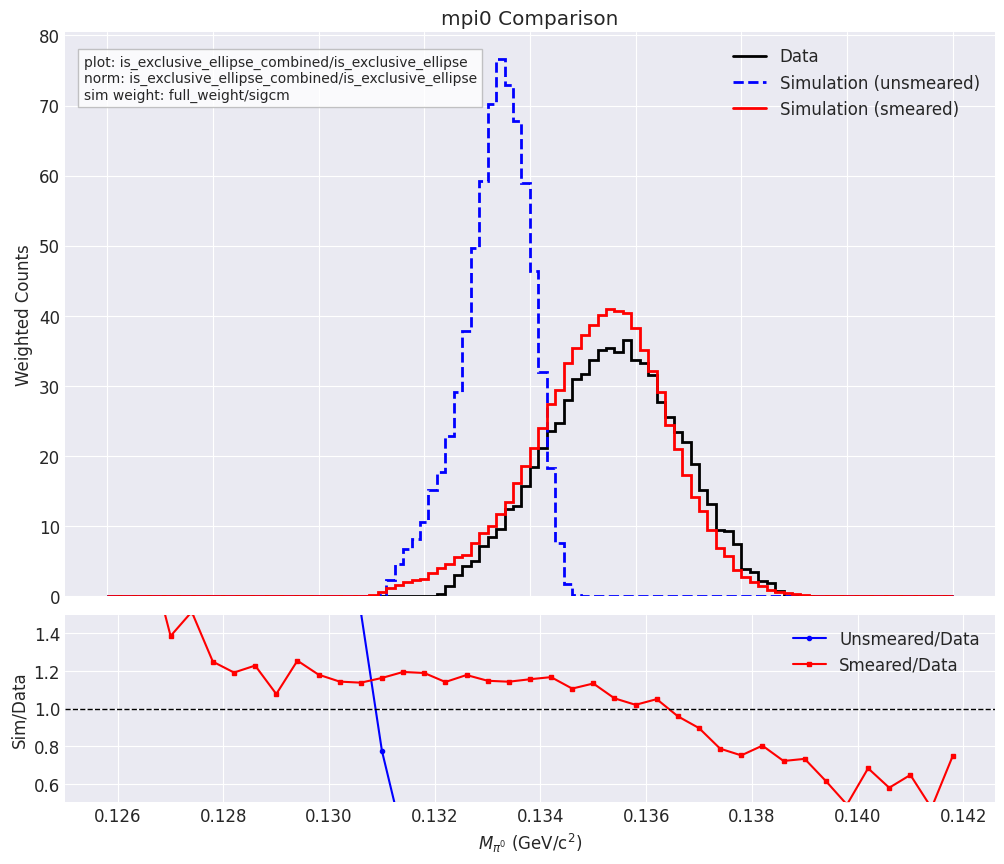

mpi0:
  Plot selection: ellipse cut
  Normalization integrals (is_exclusive_ellipse_combined vs is_exclusive_ellipse): data=716, sim=1.5747e+09, scale=4.5469e-07
  Data weighted mean/std:        0.13389 / 0.00306
  Sim weighted mean/std:         0.12835 / 0.00160
  Smeared sim weighted mean/std: 0.13326 / 0.00320


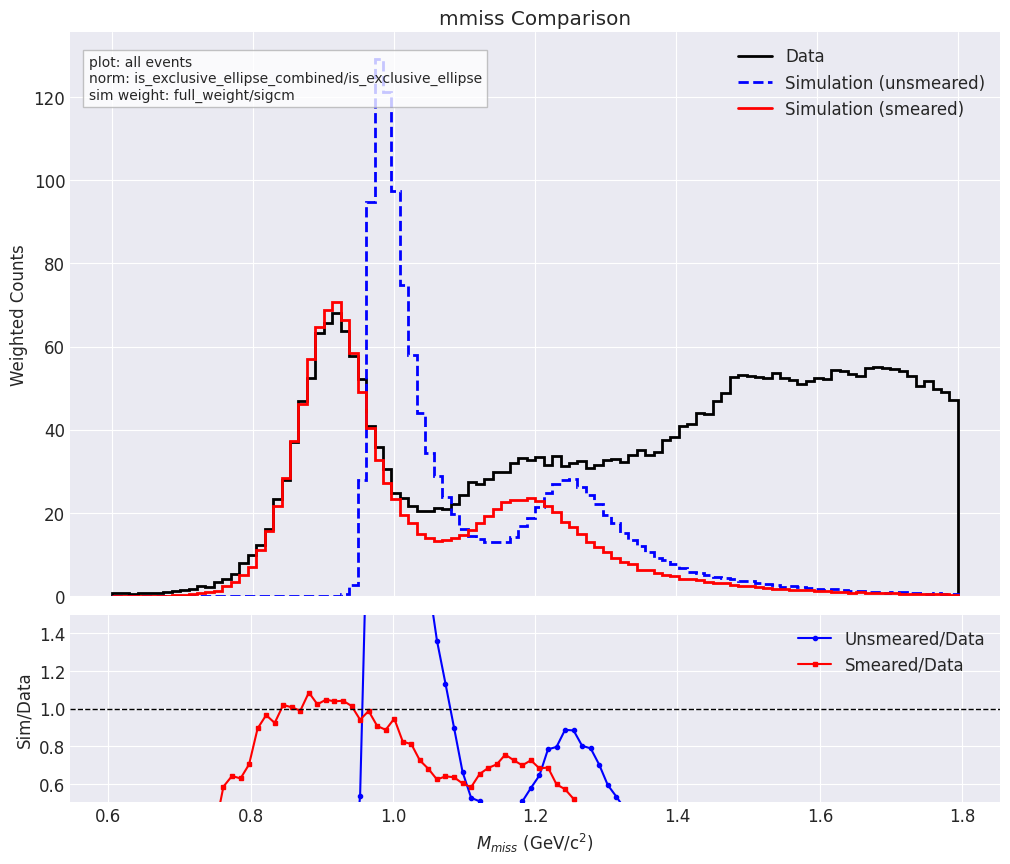

mmiss:
  Plot selection: all events
  Normalization integrals (is_exclusive_ellipse_combined vs is_exclusive_ellipse): data=716, sim=1.5747e+09, scale=4.5469e-07
  Data weighted mean/std:        1.46898 / 0.38203
  Sim weighted mean/std:         1.12064 / 0.16857
  Smeared sim weighted mean/std: 1.03958 / 0.18584


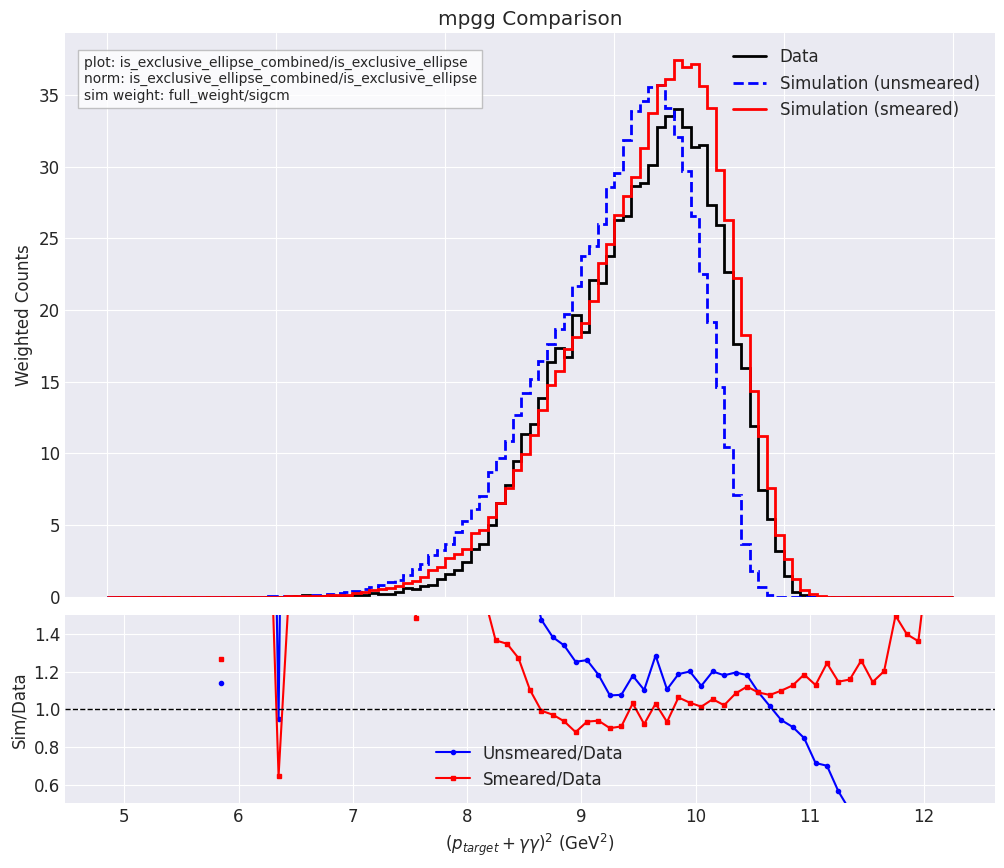

mpgg:
  Plot selection: ellipse cut
  Normalization integrals (is_exclusive_ellipse_combined vs is_exclusive_ellipse): data=716, sim=1.5747e+09, scale=4.5469e-07
  Data weighted mean/std:        10.31379 / 0.86637
  Sim weighted mean/std:         10.00791 / 0.88198
  Smeared sim weighted mean/std: 10.35627 / 0.91063


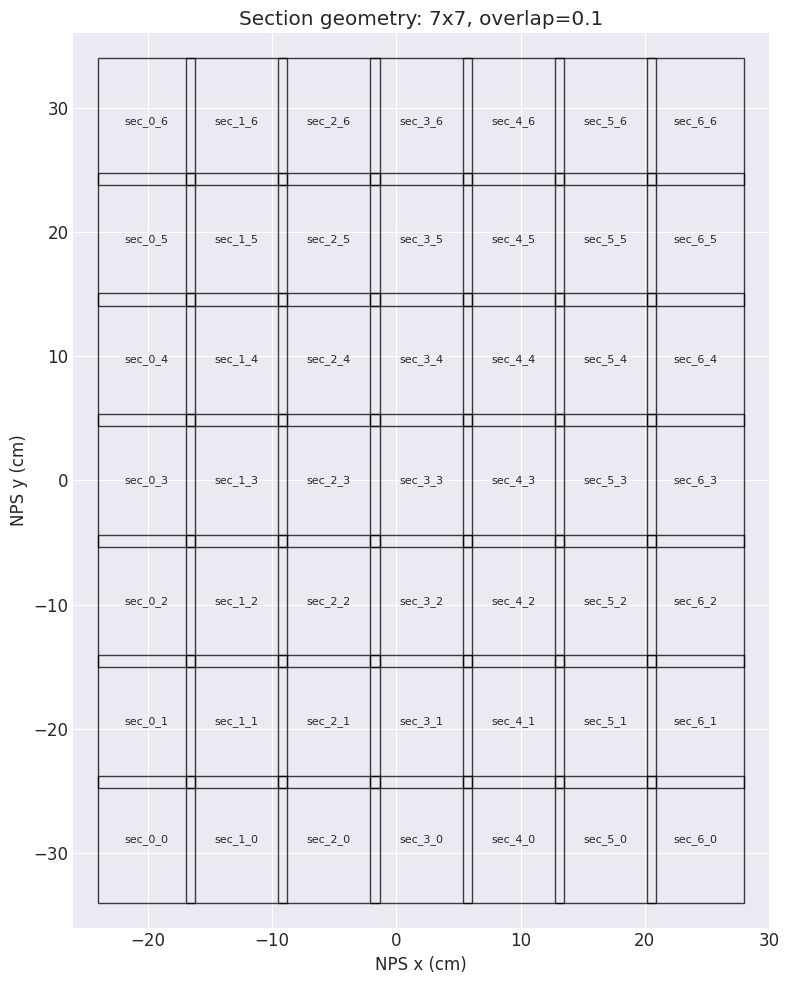

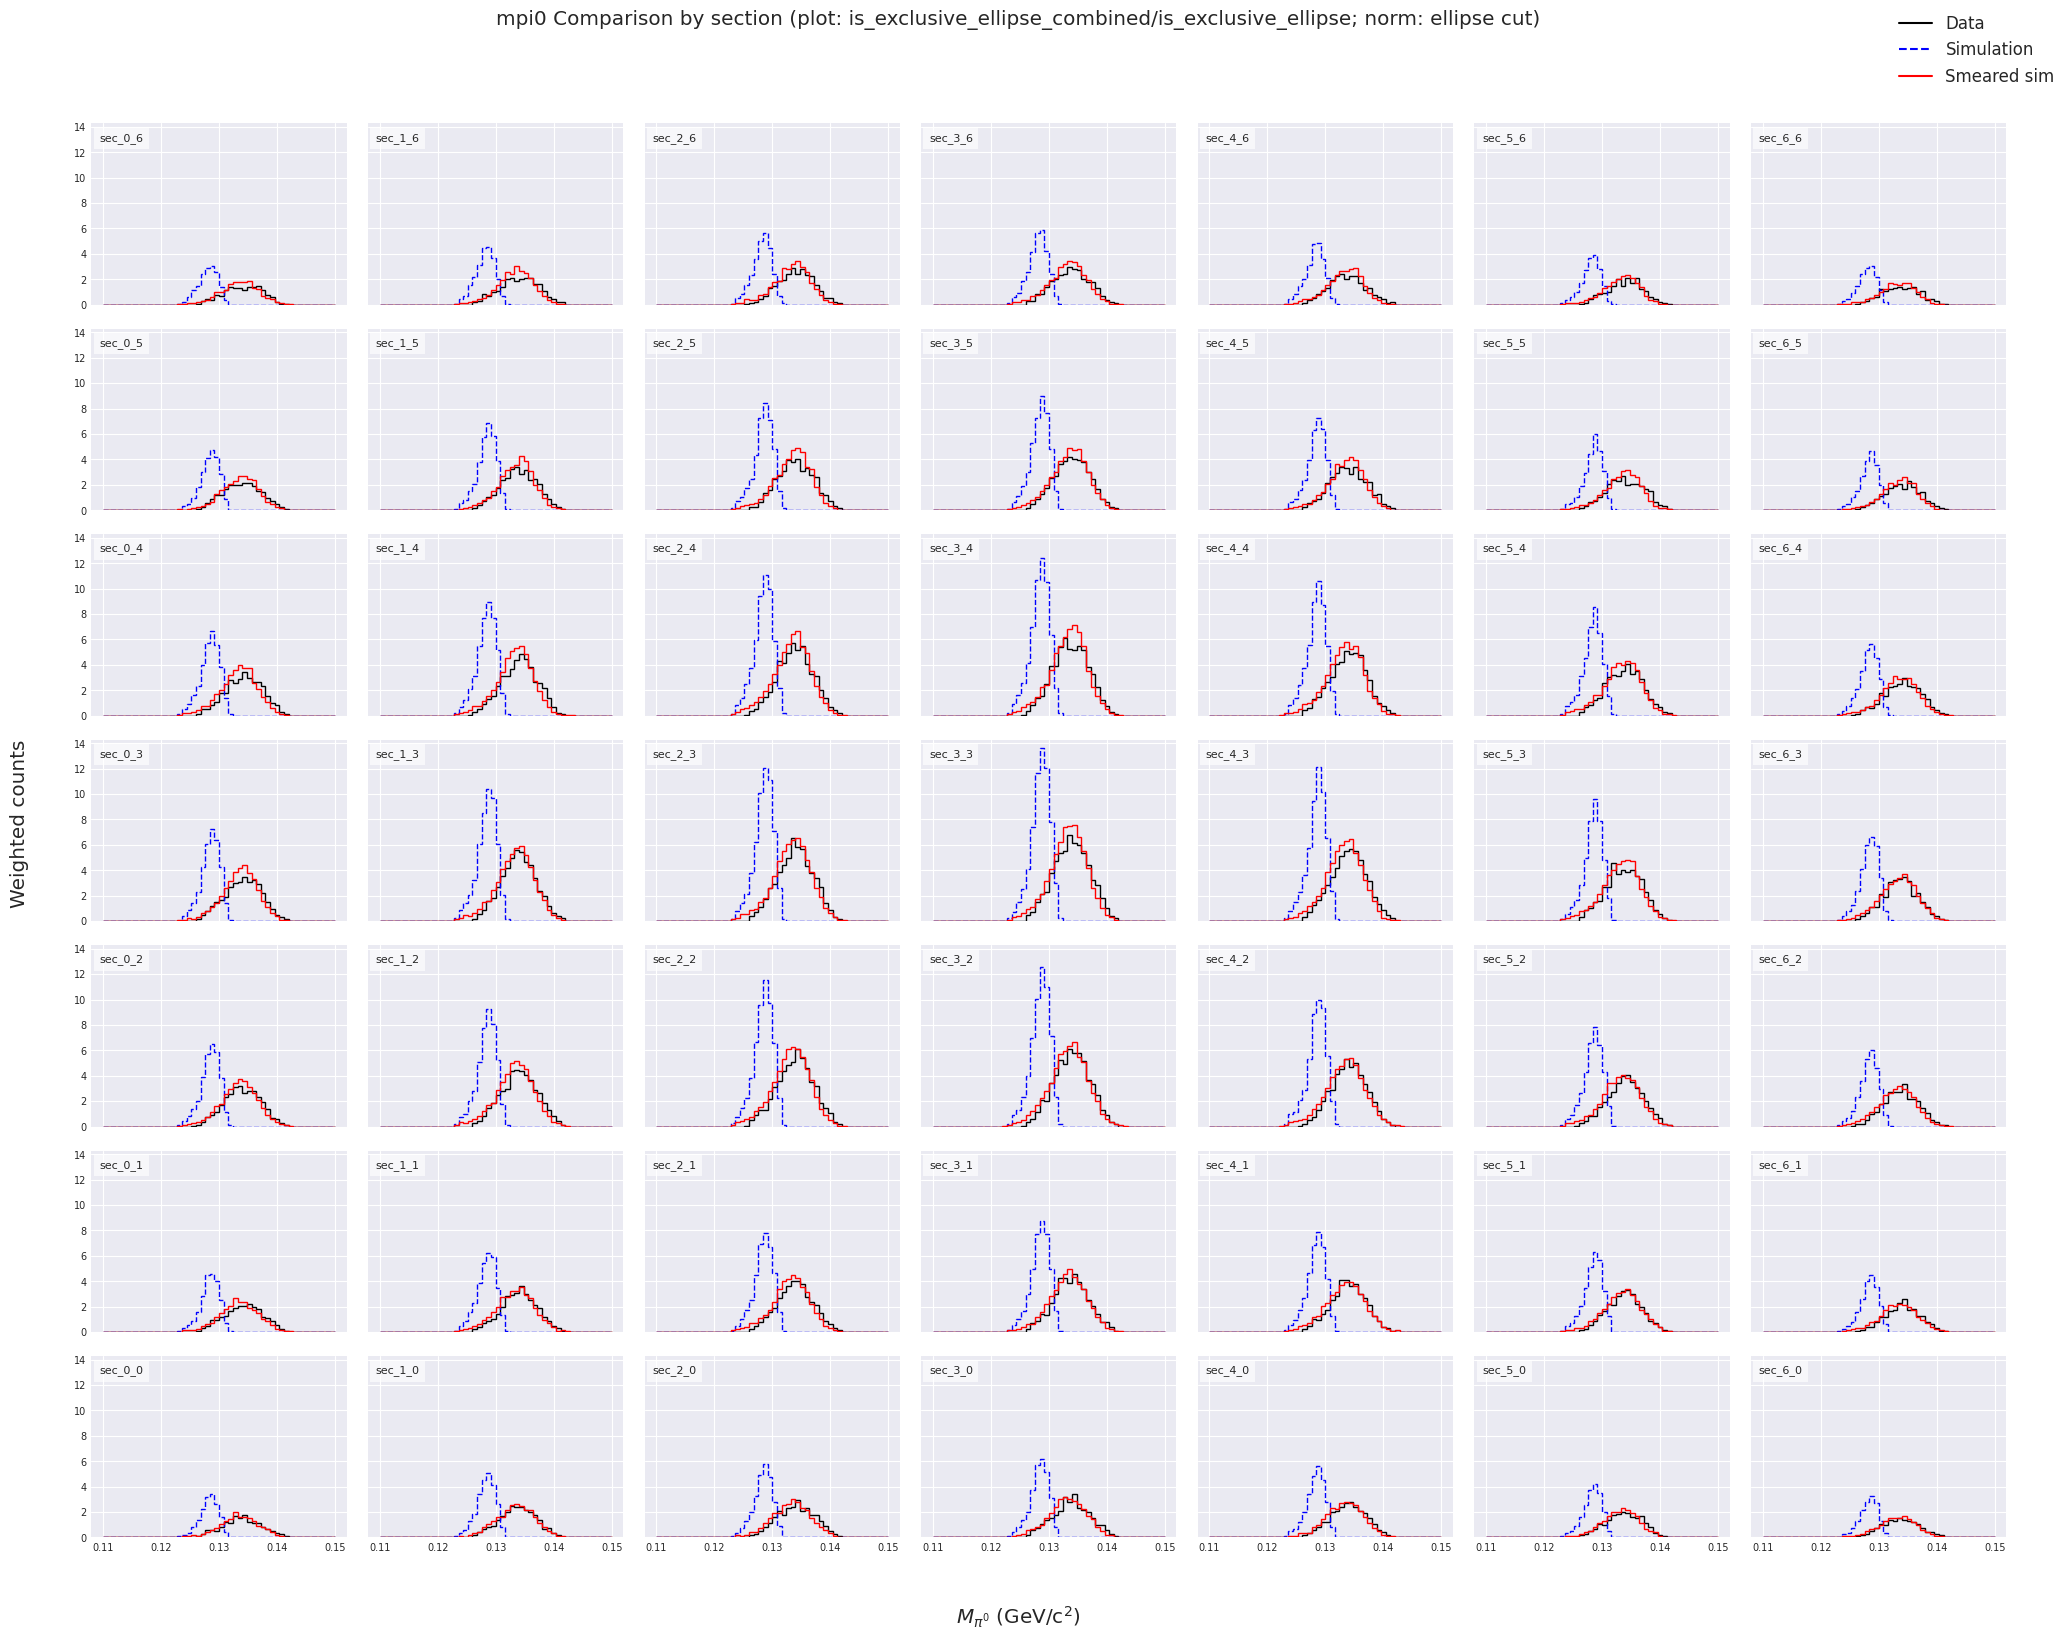

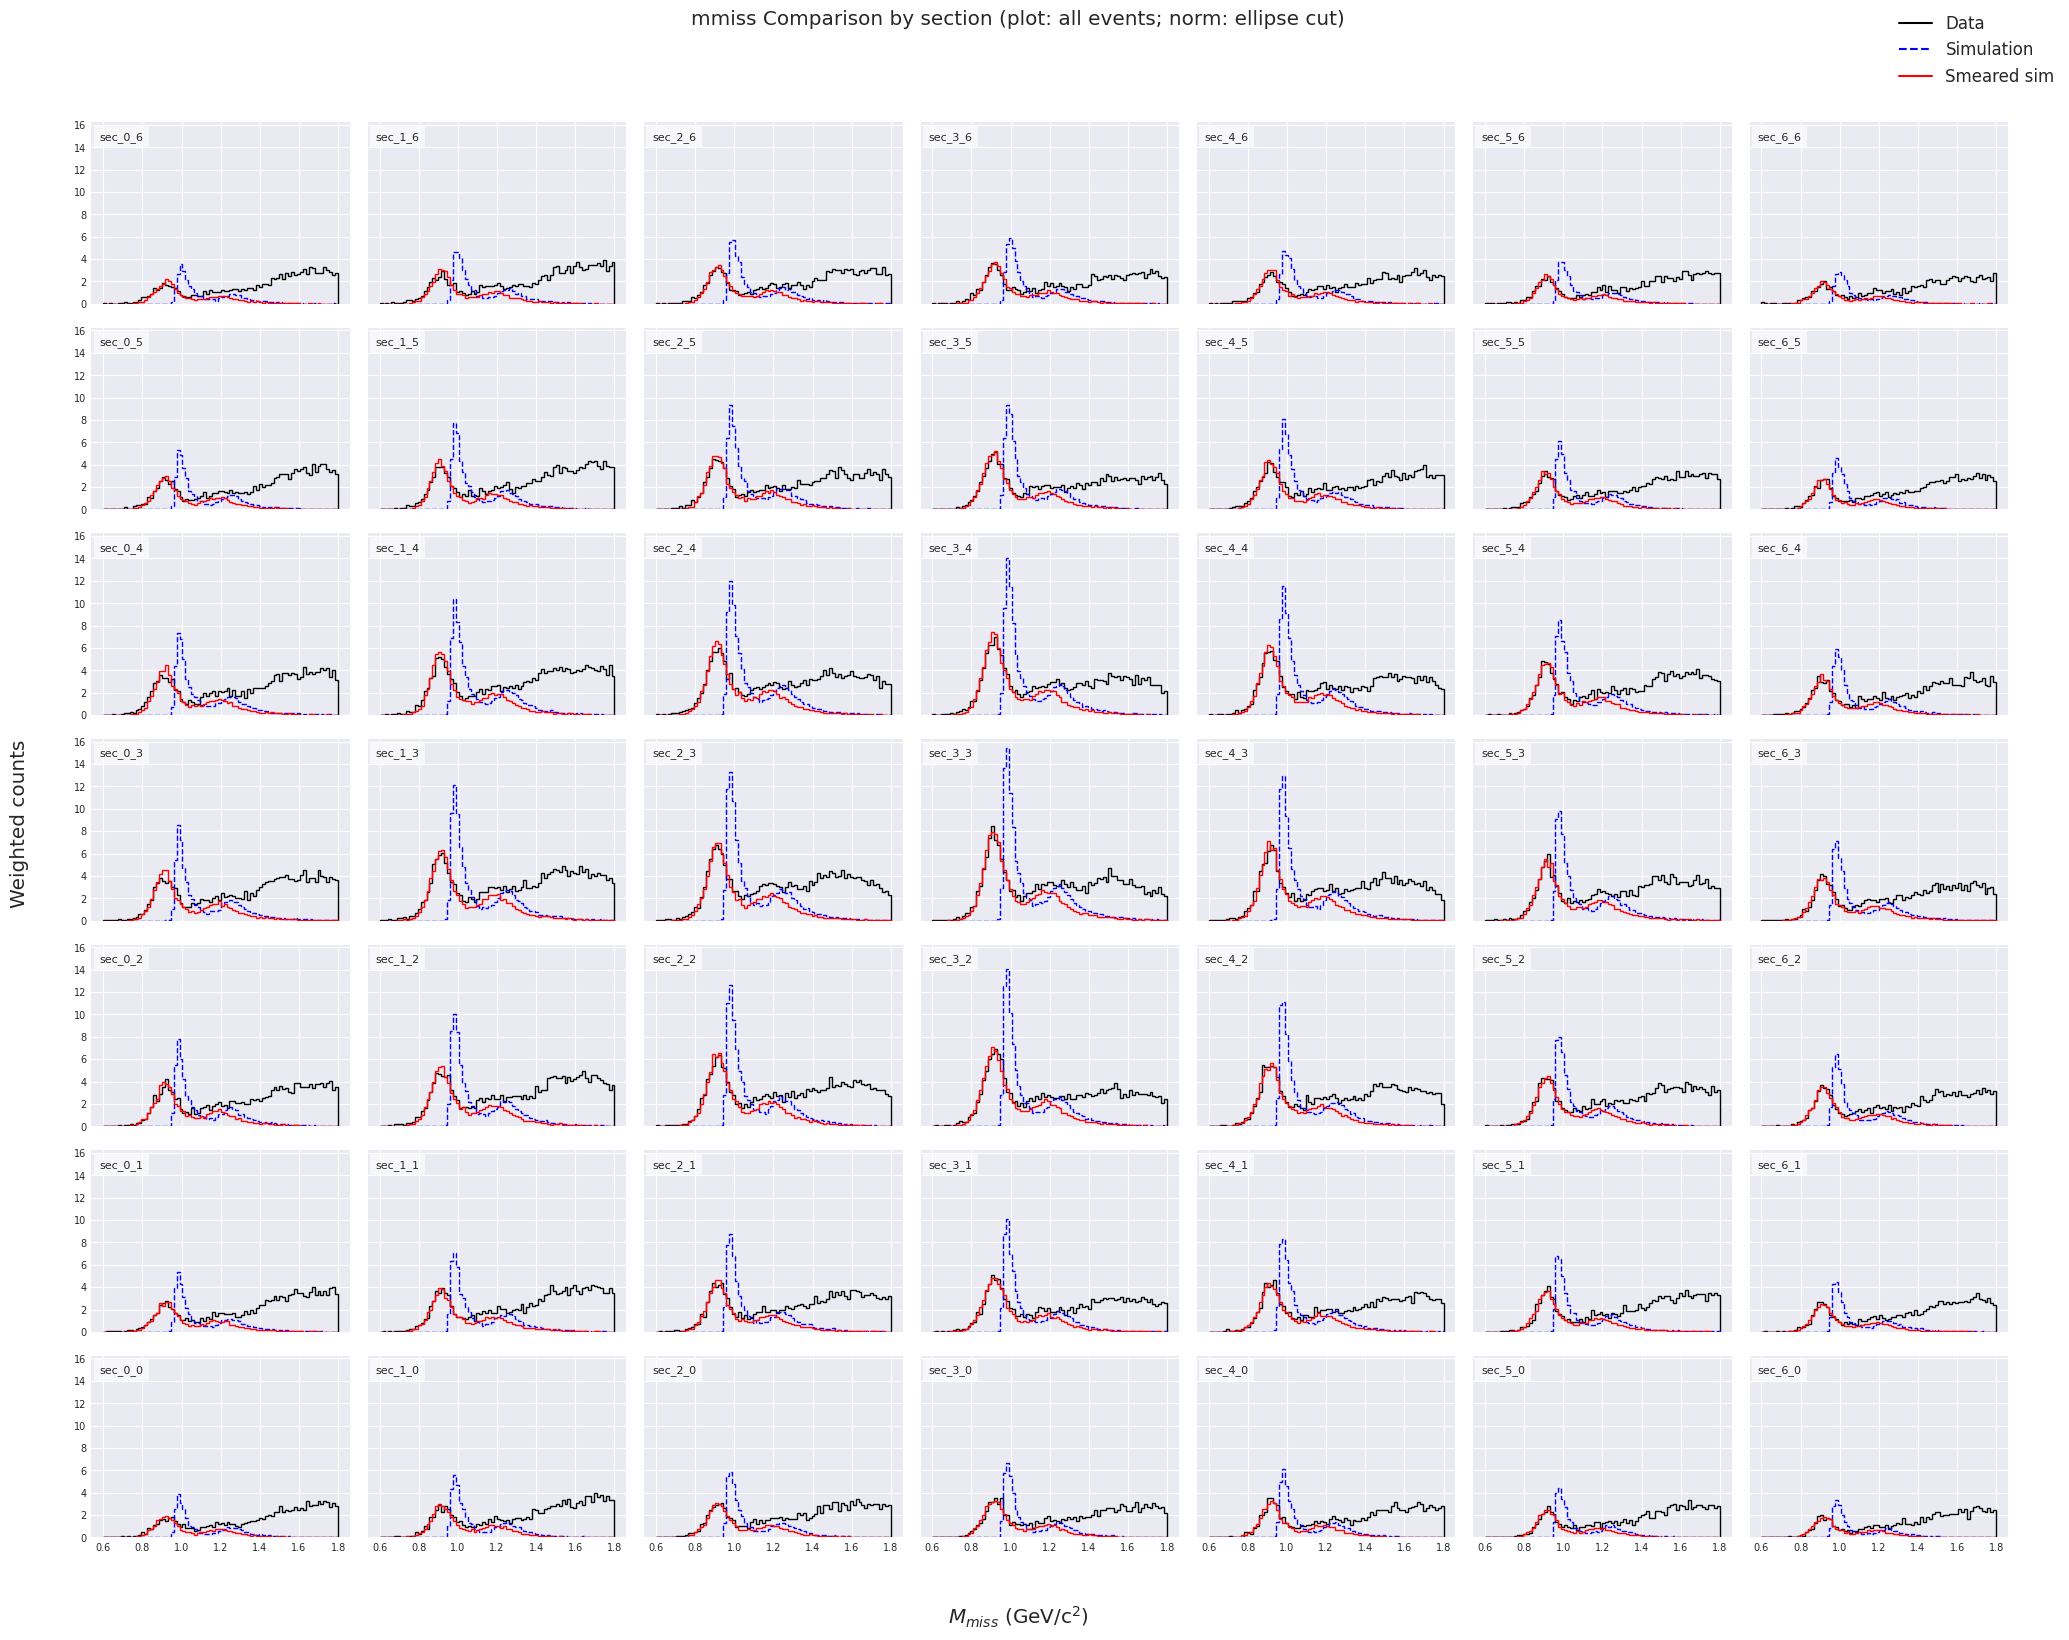

In [17]:
# Focused plots
plot_comparison('mpi0', bins=100, range_vals=(0.11, 0.15), xlabel=r'$M_{\pi^0}$ (GeV/c$^2$)', title='mpi0 Comparison')
plot_comparison('mmiss', bins=100, range_vals=(0.6, 1.8), xlabel=r'$M_{miss}$ (GeV/c$^2$)', title='mmiss Comparison')
plot_comparison('mpgg', bins=100, range_vals=(4.0, 14.0), xlabel=r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)', title='mpgg Comparison')

# Section geometry and section-by-section checks
plot_section_geometry()
plot_section_grid_comparison('mpi0', bins=50, range_vals=(0.11, 0.15), xlabel=r'$M_{\pi^0}$ (GeV/c$^2$)', title='mpi0 Comparison')
plot_section_grid_comparison('mmiss', bins=80, range_vals=(0.6, 1.8), xlabel=r'$M_{miss}$ (GeV/c$^2$)', title='mmiss Comparison')

Missing-mass peak window: 0.850 to 1.050 GeV
Selection: nclust==2, notebook energy/geometry cuts, valid full_weight/sigcm
Split: is_exclusive==0 is SIDIS input; is_exclusive==1 is exclusive input
SIDIS weighted yield:     9.42558e+06
Exclusive weighted yield: 1.54463e+09
Total weighted yield:     1.55405e+09
SIDIS fraction:           0.6065%
SIDIS/exclusive ratio:    0.00610217


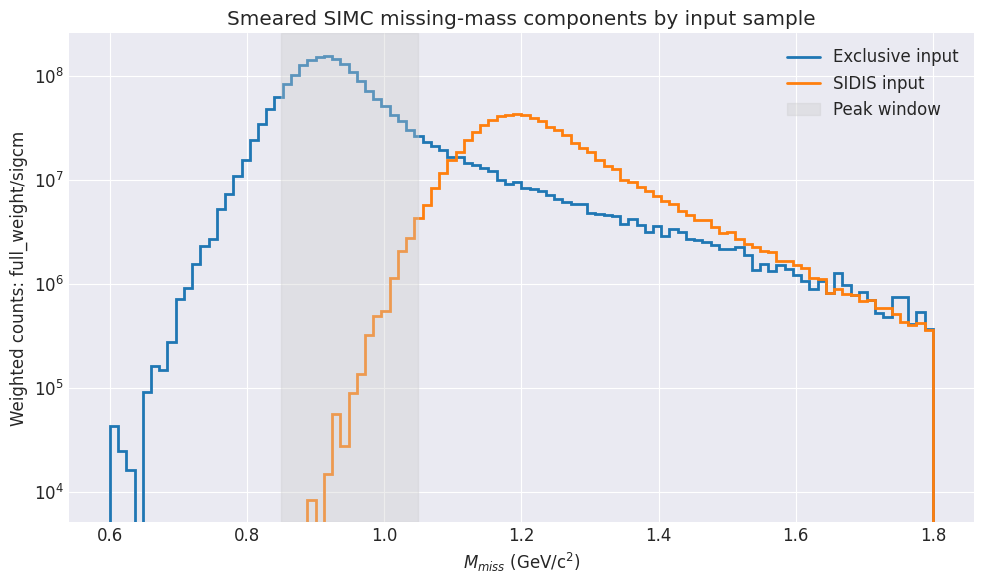

In [18]:
# SIDIS contribution under the missing-mass peak.
# This uses the producer label is_exclusive: 1 = exclusive SIMC input, 0 = SIDIS SIMC input.
# The weights are the same de-modeled smeared-SIMC weights used above: full_weight/siglab.
MMISS_PEAK_WINDOW = (0.85, 1.05)
MMISS_COMPONENT_RANGE = (0.6, 1.8)
MMISS_COMPONENT_BINS = 100

sample_label = require_branch(sim_smeared_tree, 'is_exclusive', 'smeared simulation tree').astype(int)[sim_smeared_cut]
mmiss_vals = sim_smeared['mmiss'][sim_smeared_cut].astype(float)
weights = sim_smeared_weights.astype(float)

finite = np.isfinite(mmiss_vals) & np.isfinite(weights)
peak = finite & (mmiss_vals >= MMISS_PEAK_WINDOW[0]) & (mmiss_vals <= MMISS_PEAK_WINDOW[1])
sidis = sample_label == 0
exclusive = sample_label == 1

sidis_yield = np.sum(weights[peak & sidis])
exclusive_yield = np.sum(weights[peak & exclusive])
total_yield = sidis_yield + exclusive_yield
sidis_fraction = sidis_yield / total_yield if total_yield > 0 else np.nan
sidis_to_exclusive = sidis_yield / exclusive_yield if exclusive_yield > 0 else np.nan

print(f"Missing-mass peak window: {MMISS_PEAK_WINDOW[0]:.3f} to {MMISS_PEAK_WINDOW[1]:.3f} GeV")
print(f"Selection: nclust==2, notebook energy/geometry cuts, valid full_weight/{SIM_MODEL_XSEC_BRANCH}")
print("Split: is_exclusive==0 is SIDIS input; is_exclusive==1 is exclusive input")
print(f"SIDIS weighted yield:     {sidis_yield:.6g}")
print(f"Exclusive weighted yield: {exclusive_yield:.6g}")
print(f"Total weighted yield:     {total_yield:.6g}")
print(f"SIDIS fraction:           {sidis_fraction:.4%}")
print(f"SIDIS/exclusive ratio:    {sidis_to_exclusive:.6g}")

fig, ax = plt.subplots(figsize=(10, 6))
for mask, label, color in [
    (exclusive, 'Exclusive input', 'tab:blue'),
    (sidis, 'SIDIS input', 'tab:orange'),
]:
    hist_mask = finite & mask
    counts, edges = np.histogram(
        mmiss_vals[hist_mask],
        bins=MMISS_COMPONENT_BINS,
        range=MMISS_COMPONENT_RANGE,
        weights=weights[hist_mask],
    )
    ax.stairs(counts, edges, linewidth=2, label=label, color=color)

ax.axvspan(MMISS_PEAK_WINDOW[0], MMISS_PEAK_WINDOW[1], color='0.8', alpha=0.35, label='Peak window')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{miss}$ (GeV/c$^2$)')
ax.set_ylabel(f'Weighted counts: full_weight/{SIM_MODEL_XSEC_BRANCH}')
ax.set_title('Smeared SIMC missing-mass components by input sample')
ax.legend()
plt.tight_layout()
plt.show()